In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:

# =========================================================
# 1. LOAD DATASET 1
# =========================================================
d1 = pd.read_csv("dataset1_280126.csv")

# clean column names
d1.columns = (
    d1.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "", regex=False)
)

# ensure pseudoid exists
if "pseudoid" not in d1.columns:
    guess = next(c for c in d1.columns if "pseudo" in c and "id" in c)
    d1 = d1.rename(columns={guess: "pseudoid"})

d1["pseudoid"] = d1["pseudoid"].astype(str).str.strip()

print("Dataset1 before preprocessing:", d1.shape)
display(d1.head())


Dataset1 before preprocessing: (22154, 23)


,pseudoid,weightnet,vacuumed,quantum,quantumunit,geometry,height,density,massinjar,massinjartare,...,totalvaporizationamount,totalvaporizationvolume,ashweightnet,amounttoashing,ashconcentration,srcarrierconcentration,srcarriervolume,sievedorganicweight,sievedrocksweight,sieveddryweight
0,51055,NaN,0,29093.1,m^3,g-3,3.0,0.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,52642,NaN,0,5441.8,m^3,g-7,0.0,1.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60026,NaN,0,28689.6,m^3,g-3,3.0,0.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61469,NaN,0,5569.4,m^3,g-7,0.0,1.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,77085,NaN,0,1.0,m^2,g-3,1.0,0.12,0.17,11.3096,...,33320.0,NaN,NaN,NaN,NaN,1.0,2.5,NaN,NaN,NaN


In [3]:
# =========================================================
# 2. BASIC CLEANING RULES
# =========================================================
df = d1.copy()

# ensure key columns exist so code will not break
for c in ["vacuumed", "quantum", "quantumunit", "geometry", "height", "density"]:
    if c not in df.columns:
        df[c] = np.nan

# normalize key columns
df["vacuumed"] = pd.to_numeric(df["vacuumed"], errors="coerce").fillna(0).astype(int)
df["quantum"] = pd.to_numeric(df["quantum"], errors="coerce")
df["height"] = pd.to_numeric(df["height"], errors="coerce")
df["density"] = pd.to_numeric(df["density"], errors="coerce")

df["quantumunit"] = df["quantumunit"].astype(str).str.strip().str.lower()
df.loc[df["quantumunit"].isin(["", "nan", "none"]), "quantumunit"] = np.nan

before_rows = len(df)

# Rule 1
# remove rows where only pseudoid and vacuumed exist
cols_other_than_id_vac = [c for c in df.columns if c not in ["pseudoid", "vacuumed"]]
rule_only_id_vac = df[cols_other_than_id_vac].isna().all(axis=1)

# Rule 2
# remove laaduton placeholders
allowed = ["pseudoid", "vacuumed", "quantum", "quantumunit", "geometry", "height", "density"]
outside_allowed = [c for c in df.columns if c not in allowed]
nothing_outside = df[outside_allowed].isna().all(axis=1)

rule_laaduton_placeholder = (
    (df["quantumunit"] == "laaduton") &
    (df["density"] == 1) &
    (df["quantum"] == 1) &
    nothing_outside
)

drop_mask = rule_only_id_vac | rule_laaduton_placeholder
df = df.loc[~drop_mask].copy()

after_clean_rows = len(df)

report_cleaning = pd.DataFrame({
    "removed_reason": [
        "only pseudoid and vacuumed present",
        "laaduton placeholder pattern",
        "total removed"
    ],
    "rows_removed": [
        int(rule_only_id_vac.sum()),
        int(rule_laaduton_placeholder.sum()),
        int(before_rows - after_clean_rows)
    ]
})

print("Dataset1 after basic cleaning:", df.shape)
print("Removed percentage:", round(100 * (before_rows - after_clean_rows) / before_rows, 2), "%")
display(report_cleaning)



Dataset1 after basic cleaning: (20095, 23)
Removed percentage: 9.29 %


,removed_reason,rows_removed
0,only pseudoid and vacuumed present,1323
1,laaduton placeholder pattern,736
2,total removed,2059


In [4]:
# =========================================================
# 3. QUALITY FLAGS
# keep these as information
# do not remove rows yet unless you want a stricter version
# =========================================================
for c in ["massinjar", "massinjartare", "massinjargross", "dryweightnet", "dryweightpercent", "ashweightnet", "weightnet"]:
    if c not in df.columns:
        df[c] = np.nan

df["massinjar"] = pd.to_numeric(df["massinjar"], errors="coerce")
df["massinjartare"] = pd.to_numeric(df["massinjartare"], errors="coerce")
df["massinjargross"] = pd.to_numeric(df["massinjargross"], errors="coerce")
df["dryweightnet"] = pd.to_numeric(df["dryweightnet"], errors="coerce")
df["dryweightpercent"] = pd.to_numeric(df["dryweightpercent"], errors="coerce")
df["ashweightnet"] = pd.to_numeric(df["ashweightnet"], errors="coerce")
df["weightnet"] = pd.to_numeric(df["weightnet"], errors="coerce")

df["gross_less_than_tare"] = (df["massinjargross"] < df["massinjartare"]).fillna(False).astype(int)
df["dry_gt_netwet"] = (df["dryweightnet"] > df["weightnet"]).fillna(False).astype(int)
df["ash_gt_dry"] = (df["ashweightnet"] > df["dryweightnet"]).fillna(False).astype(int)
df["dry_percent_gt_100"] = (df["dryweightpercent"] > 100).fillna(False).astype(int)
df["density_nonpositive"] = (df["density"] <= 0).fillna(False).astype(int)

df["quality_error"] = (
    (df["gross_less_than_tare"] == 1) |
    (df["dry_gt_netwet"] == 1) |
    (df["ash_gt_dry"] == 1) |
    (df["dry_percent_gt_100"] == 1) |
    (df["density_nonpositive"] == 1)
).astype(int)

violation_summary = pd.DataFrame({
    "violations": [
        int(df["gross_less_than_tare"].sum()),
        int(df["dry_gt_netwet"].sum()),
        int(df["ash_gt_dry"].sum()),
        int(df["dry_percent_gt_100"].sum()),
        int(df["density_nonpositive"].sum()),
        int(df["quality_error"].sum())
    ]
}, index=[
    "gross_less_than_tare",
    "dry_gt_netwet",
    "ash_gt_dry",
    "dry_percent_gt_100",
    "density_nonpositive",
    "quality_error_any"
])

display(violation_summary)


,violations
gross_less_than_tare,10
dry_gt_netwet,25
ash_gt_dry,0
dry_percent_gt_100,10
density_nonpositive,10
quality_error_any,47


In [5]:
# =========================================================
# 4. PROCESS FLAGS
# these capture workflow information
# =========================================================
process_groups = {
    "has_mass_in_jar": ["massinjar", "massinjartare", "massinjargross"],
    "has_drying": ["dryweightnet", "dryweightpercent"],
    "has_vaporization": ["totalvaporizationamount", "totalvaporizationvolume"],
    "has_ashing": ["ashweightnet", "amounttoashing", "ashconcentration"],
    "has_sr_carrier": ["srcarrierconcentration", "srcarriervolume"],
    "has_sieving": ["sievedorganicweight", "sievedrocksweight", "sieveddryweight"]
}

for flag, cols in process_groups.items():
    existing = [c for c in cols if c in df.columns]
    if existing:
        df[flag] = df[existing].notna().any(axis=1).astype(int)
    else:
        df[flag] = 0


In [6]:
# =========================================================
# 5. CREATE MISSING INDICATOR FEATURES
# missingness itself is meaningful here
# =========================================================
X_all = df.drop(columns=["pseudoid"]).copy()

missing_flags = X_all.isnull().astype(int)
missing_flags.columns = [f"{c}_missing" for c in X_all.columns]

In [7]:
# =========================================================
# 6. NUMERIC AND CATEGORICAL SPLIT
# =========================================================
numeric_cols = X_all.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_all.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Categorical names:", categorical_cols)


Numeric columns: 32
Categorical columns: 2
Categorical names: ['quantumunit', 'geometry']


In [8]:
# =========================================================
# 7. NUMERIC IMPUTATION
# drop very sparse numeric columns automatically
# =========================================================
numeric_df = X_all[numeric_cols].copy()

sparse_threshold = 0.80
drop_sparse_numeric = [c for c in numeric_df.columns if numeric_df[c].isna().mean() > sparse_threshold]

numeric_df = numeric_df.drop(columns=drop_sparse_numeric)

for c in numeric_df.columns:
    numeric_df[c] = pd.to_numeric(numeric_df[c], errors="coerce")
    numeric_df[c] = numeric_df[c].fillna(numeric_df[c].median())

print("Dropped sparse numeric columns >", sparse_threshold, "missing:")
print(drop_sparse_numeric)

Dropped sparse numeric columns > 0.8 missing:
['dryweightpercent', 'totalvaporizationamount', 'totalvaporizationvolume', 'ashweightnet', 'amounttoashing', 'ashconcentration', 'srcarrierconcentration', 'srcarriervolume', 'sievedorganicweight', 'sievedrocksweight', 'sieveddryweight']


In [9]:
# =========================================================
# 8. CATEGORICAL ENCODING
# one hot encode automatically
# =========================================================
if len(categorical_cols) > 0:
    cat_df = pd.get_dummies(X_all[categorical_cols], prefix=categorical_cols, dummy_na=False)
else:
    cat_df = pd.DataFrame(index=X_all.index)

print("Encoded categorical shape:", cat_df.shape)

Encoded categorical shape: (20095, 20)


In [10]:
# =========================================================
# 9. ALIGN MISSING FLAGS
# remove missing flags for dropped sparse numeric columns
# =========================================================
drop_missing_flag_cols = [f"{c}_missing" for c in drop_sparse_numeric if f"{c}_missing" in missing_flags.columns]
missing_flags_final = missing_flags.drop(columns=drop_missing_flag_cols, errors="ignore")



In [11]:
# =========================================================
# 10. FINAL FEATURE MATRIX
# =========================================================
X_final_df = pd.concat(
    [
        numeric_df.reset_index(drop=True),
        cat_df.reset_index(drop=True),
        missing_flags_final.reset_index(drop=True)
    ],
    axis=1
)

# remove duplicate columns if any
X_final_df = X_final_df.loc[:, ~X_final_df.columns.duplicated()].copy()

# convert everything to numeric just in case
X_final_df = X_final_df.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Final feature matrix shape before scaling:", X_final_df.shape)
display(X_final_df.head())

Final feature matrix shape before scaling: (20095, 64)


,weightnet,vacuumed,quantum,height,density,massinjar,massinjartare,massinjargross,dryweightnet,gross_less_than_tare,...,ash_gt_dry_missing,dry_percent_gt_100_missing,density_nonpositive_missing,quality_error_missing,has_mass_in_jar_missing,has_drying_missing,has_vaporization_missing,has_ashing_missing,has_sr_carrier_missing,has_sieving_missing
0,565.65,0,29093.1,3.0,0.70,54.31,26.7700,80.1450,121.335,0,...,0,0,0,0,0,0,0,0,0,0
1,565.65,0,5441.8,0.0,1.00,54.31,26.7700,80.1450,121.335,0,...,0,0,0,0,0,0,0,0,0,0
2,565.65,0,28689.6,3.0,0.70,54.31,26.7700,80.1450,121.335,0,...,0,0,0,0,0,0,0,0,0,0
3,565.65,0,5569.4,0.0,1.00,54.31,26.7700,80.1450,121.335,0,...,0,0,0,0,0,0,0,0,0,0
4,565.65,0,1.0,1.0,0.12,0.17,11.3096,11.4794,121.335,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# =========================================================
# 11. SCALE FEATURES
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final_df)

print("Scaled matrix shape:", X_scaled.shape)


Scaled matrix shape: (20095, 64)


In [13]:
# =========================================================
# 12. OPTIONAL PCA FOR MEAN SHIFT
# keep enough variance before Mean Shift
# =========================================================
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance by PCA:", round(pca.explained_variance_ratio_.sum(), 4))


PCA shape: (20095, 28)
Explained variance by PCA: 0.9511


In [14]:
# =========================================================
# 13. SAVE OUTPUTS FOR LATER METHODS
# =========================================================
feature_names = X_final_df.columns.tolist()
pseudoids_final = df["pseudoid"].reset_index(drop=True)

print("Ready for Mean Shift with X_pca")
print("Ready for Autoencoder with X_scaled")
print("Number of final samples:", len(pseudoids_final))
print("Number of final features:", len(feature_names))

Ready for Mean Shift with X_pca
Ready for Autoencoder with X_scaled
Number of final samples: 20095
Number of final features: 64


In [15]:
from sklearn.cluster import MeanShift, estimate_bandwidth
import numpy as np
import pandas as pd

bandwidth = estimate_bandwidth(X_pca, quantile=0.2, n_samples=min(5000, len(X_pca)))

print("Estimated bandwidth:", bandwidth)

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_pca)

n_clusters_ms = len(np.unique(labels_ms))
print("Number of Mean Shift clusters:", n_clusters_ms)

Estimated bandwidth: 6.5606800646073316
Number of Mean Shift clusters: 12


In [16]:
cluster_counts_ms = pd.Series(labels_ms).value_counts().sort_values(ascending=False)

print(cluster_counts_ms)

0     17150
1      1024
2       525
3       456
4       304
5       258
6       214
7        77
9        57
8        25
10        4
11        1
Name: count, dtype: int64


In [17]:
meanshift_df = pd.DataFrame({
    "pseudoid": pseudoids_final,
    "cluster": labels_ms
})

display(meanshift_df.head())
print("Mean Shift result shape:", meanshift_df.shape)

,pseudoid,cluster
0,51055,0
1,52642,0
2,60026,0
3,61469,0
4,77085,0


Mean Shift result shape: (20095, 2)


In [18]:
top_n = 6
top_clusters = cluster_counts_ms.head(top_n).index.tolist()

labels_ms_plot = np.array([
    c if c in top_clusters else -1
    for c in labels_ms
])

print("Top clusters used in plot:", top_clusters)
print("Rare cluster points:", (labels_ms_plot == -1).sum())

Top clusters used in plot: [0, 1, 2, 3, 4, 5]
Rare cluster points: 378


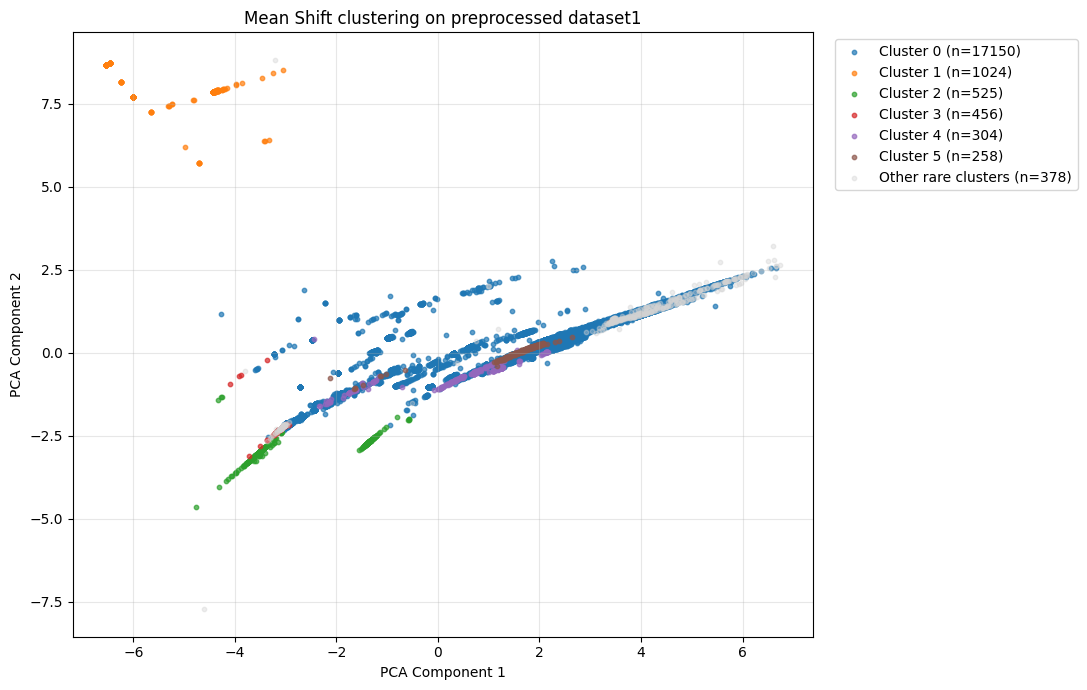

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

for c in top_clusters:
    idx = labels_ms_plot == c
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=10,
        alpha=0.7,
        label=f"Cluster {c} (n={cluster_counts_ms[c]})"
    )

idx_other = labels_ms_plot == -1
if idx_other.sum() > 0:
    plt.scatter(
        X_pca[idx_other, 0],
        X_pca[idx_other, 1],
        s=10,
        alpha=0.4,
        color="lightgray",
        label=f"Other rare clusters (n={idx_other.sum()})"
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Mean Shift clustering on preprocessed dataset1")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

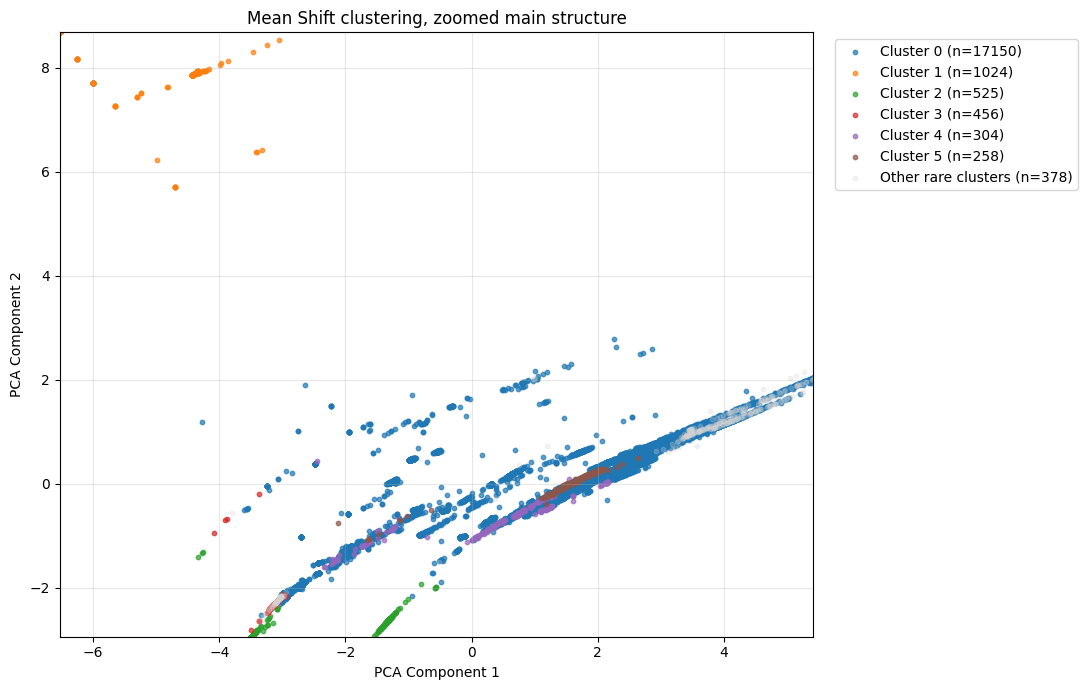

In [20]:
plt.figure(figsize=(11, 7))

for c in top_clusters:
    idx = labels_ms_plot == c
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=10,
        alpha=0.7,
        label=f"Cluster {c} (n={cluster_counts_ms[c]})"
    )

idx_other = labels_ms_plot == -1
if idx_other.sum() > 0:
    plt.scatter(
        X_pca[idx_other, 0],
        X_pca[idx_other, 1],
        s=10,
        alpha=0.25,
        color="lightgray",
        label=f"Other rare clusters (n={idx_other.sum()})"
    )

x_low, x_high = np.percentile(X_pca[:, 0], [1, 99])
y_low, y_high = np.percentile(X_pca[:, 1], [1, 99])

plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Mean Shift clustering, zoomed main structure")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

if n_clusters_ms > 1:
    ms_silhouette = silhouette_score(X_pca, labels_ms)
    print("Mean Shift silhouette score:", ms_silhouette)
else:
    ms_silhouette = np.nan
    print("Silhouette score cannot be computed because only one cluster was found.")

Mean Shift silhouette score: 0.31772290556493277


In [22]:
meanshift_summary = pd.DataFrame({
    "cluster": cluster_counts_ms.index,
    "cluster_size": cluster_counts_ms.values
})

meanshift_summary["cluster_type"] = np.where(
    meanshift_summary["cluster_size"] >= 500,
    "dominant_or_major",
    np.where(
        meanshift_summary["cluster_size"] >= 50,
        "medium",
        "rare_or_anomalous"
    )
)

display(meanshift_summary)

,cluster,cluster_size,cluster_type
0,0,17150,dominant_or_major
1,1,1024,dominant_or_major
2,2,525,dominant_or_major
3,3,456,medium
4,4,304,medium
5,5,258,medium
6,6,214,medium
7,7,77,medium
8,9,57,medium
9,8,25,rare_or_anomalous


auto 


In [23]:
import torch
from torch import nn

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

print("Tensor shape:", X_tensor.shape)

Tensor shape: torch.Size([20095, 64])


In [24]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [25]:
input_dim = X_scaled.shape[1]
model = Autoencoder(input_dim=input_dim, latent_dim=2)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
  )
)


In [26]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [27]:
epochs = 50
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    
    x_hat = model(X_tensor)
    loss = criterion(x_hat, X_tensor)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 10/50, Loss: 0.782424
Epoch 20/50, Loss: 0.767910
Epoch 30/50, Loss: 0.739895
Epoch 40/50, Loss: 0.689256
Epoch 50/50, Loss: 0.634361


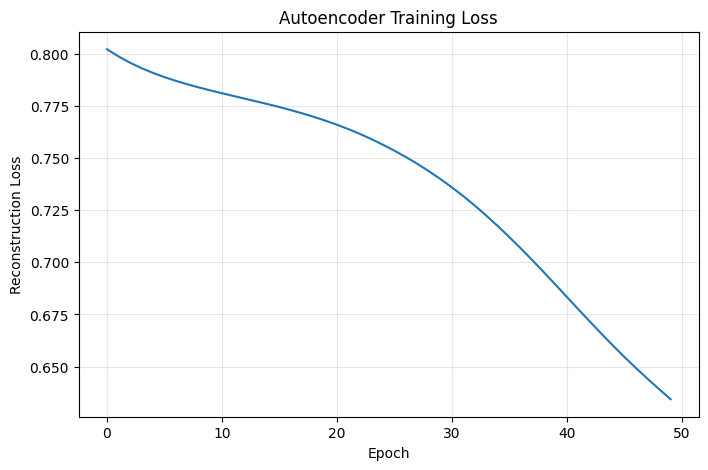

In [28]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.grid(alpha=0.3)
plt.show()

In [29]:
with torch.no_grad():
    Z = model.encoder(X_tensor).numpy()

print("Latent representation shape:", Z.shape)

Latent representation shape: (20095, 2)


In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
latent_labels = kmeans.fit_predict(Z)

cluster_counts_ae = pd.Series(latent_labels).value_counts().sort_index()

print("Autoencoder cluster counts:")
print(cluster_counts_ae)

Autoencoder cluster counts:
0    2439
1    1678
2    1038
3      46
4    8881
5    6013
Name: count, dtype: int64


In [31]:
ae_silhouette = silhouette_score(Z, latent_labels)
print("Autoencoder clustering silhouette score:", ae_silhouette)

Autoencoder clustering silhouette score: 0.5847169


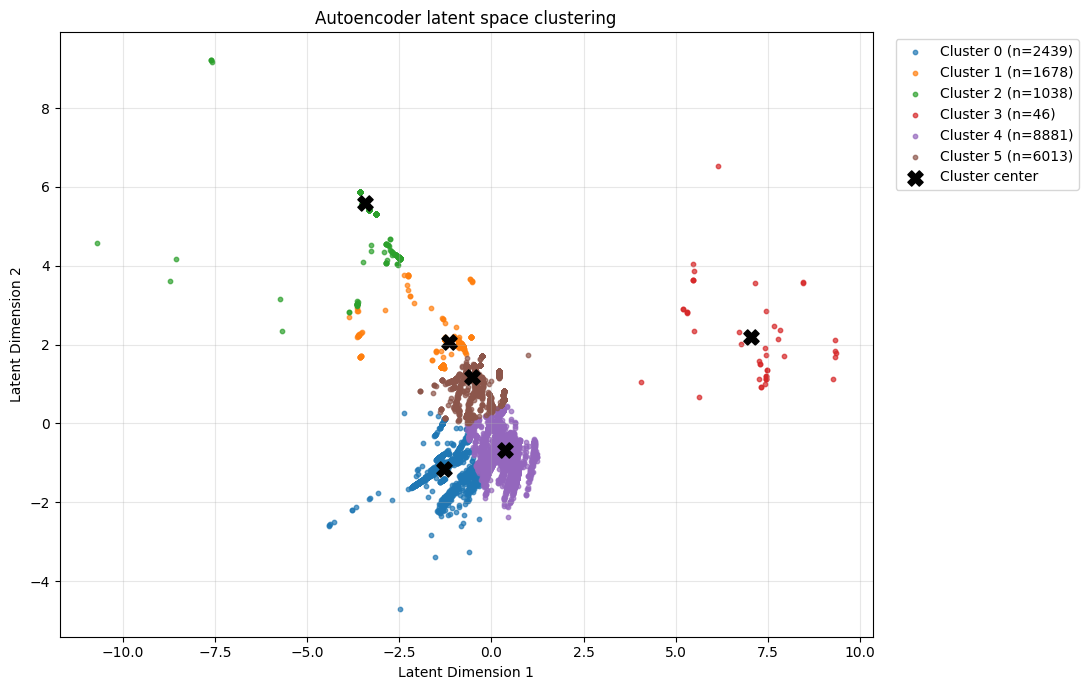

In [32]:
plt.figure(figsize=(11,7))

for i in sorted(cluster_counts_ae.index):
    idx = latent_labels == i
    plt.scatter(
        Z[idx, 0],
        Z[idx, 1],
        s=10,
        alpha=0.7,
        label=f"Cluster {i} (n={cluster_counts_ae[i]})"
    )

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=120,
    marker="X",
    label="Cluster center"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Autoencoder latent space clustering")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

validation


In [33]:
import pandas as pd

with open("dataset0.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

table_lines = [line.strip() for line in lines if line.strip().startswith("|")]

rows = []
for line in table_lines:
    parts = [x.strip() for x in line.strip("|").split("|")]
    rows.append(parts)

df0 = pd.DataFrame(rows[1:], columns=rows[0])
df0.columns = [c.strip().lower() for c in df0.columns]

df0["pseudoid"] = pd.to_numeric(df0["pseudoid"], errors="coerce").astype("Int64")
df0_small = df0[["pseudoid", "sampleclass"]].copy()

print(df0_small.shape)
display(df0_small.head())

(30707, 2)


,pseudoid,sampleclass
0,51055,C-1
1,52642,C-1
2,60026,C-1
3,61469,C-1
4,77085,C-2


In [34]:
meanshift_df = pd.DataFrame({
    "pseudoid": pd.to_numeric(pseudoids_final, errors="coerce").astype("Int64"),
    "cluster": labels_ms
})

display(meanshift_df.head())

,pseudoid,cluster
0,51055,0
1,52642,0
2,60026,0
3,61469,0
4,77085,0


In [35]:
merged_ms = meanshift_df.merge(
    df0_small,
    on="pseudoid",
    how="left"
)

print("Merged Mean Shift shape:", merged_ms.shape)
print("Missing sampleclass:", merged_ms["sampleclass"].isna().sum())
display(merged_ms.head())

Merged Mean Shift shape: (20095, 3)
Missing sampleclass: 0


,pseudoid,cluster,sampleclass
0,51055,0,C-1
1,52642,0,C-1
2,60026,0,C-1
3,61469,0,C-1
4,77085,0,C-2


In [36]:
cluster_vs_class_ms = pd.crosstab(
    merged_ms["cluster"],
    merged_ms["sampleclass"]
)

display(cluster_vs_class_ms)

sampleclass,C-0,C-1,C-10,C-11,C-12,C-13,C-14,C-15,C-16,C-17,...,C-38,C-39,C-4,C-40,C-41,C-5,C-6,C-8,C-9,NULL
cluster,,,,,,,,,,,,,,,,,,,,,
0,4,4702,920,93,49,162,145,52,6,8,...,425,256,1313,1269,37,407,117,160,216,2
1,0,1,16,0,0,0,7,2,0,1,...,3,1,61,29,0,0,67,0,0,0
2,0,525,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,456,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,8,0,0,0,0,0,0,0,0,...,0,34,1,55,0,0,0,0,1,0
5,0,0,214,0,0,0,0,0,7,1,...,1,4,3,0,0,0,0,1,8,0
6,0,0,0,0,0,0,0,0,0,0,...,3,0,0,0,0,0,0,0,0,0
7,0,77,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,0,2,0,0,0,0


In [37]:
dominant_class_ms = cluster_vs_class_ms.idxmax(axis=1)
dominant_count_ms = cluster_vs_class_ms.max(axis=1)
cluster_size_ms = cluster_vs_class_ms.sum(axis=1)

validation_ms = pd.DataFrame({
    "dominant_sampleclass": dominant_class_ms,
    "dominant_count": dominant_count_ms,
    "cluster_size": cluster_size_ms,
    "purity": dominant_count_ms / cluster_size_ms
}).sort_values("cluster_size", ascending=False)

display(validation_ms)

,dominant_sampleclass,dominant_count,cluster_size,purity
cluster,,,,
0,C-1,4702,17150,0.274169
1,C-2,810,1024,0.791016
2,C-1,525,525,1.000000
3,C-1,456,456,1.000000
4,C-31,183,304,0.601974
5,C-10,214,258,0.829457
6,C-3,211,214,0.985981
7,C-1,77,77,1.000000
9,C-33,41,57,0.719298


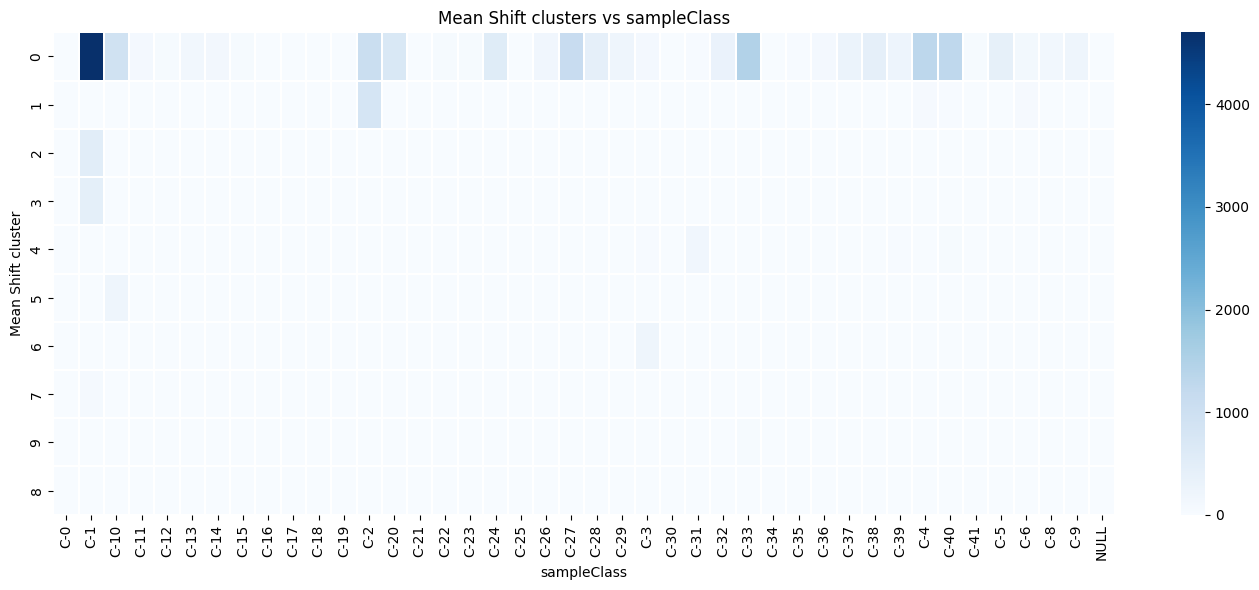

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

top_ms_clusters = validation_ms.head(10).index
heatmap_ms = cluster_vs_class_ms.loc[top_ms_clusters]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_ms, cmap="Blues", linewidths=0.3)
plt.title("Mean Shift clusters vs sampleClass")
plt.xlabel("sampleClass")
plt.ylabel("Mean Shift cluster")
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

valid_ms = merged_ms.dropna(subset=["sampleclass"]).copy()

true_ms = valid_ms["sampleclass"].astype("category").cat.codes
pred_ms = valid_ms["cluster"]

ari_ms = adjusted_rand_score(true_ms, pred_ms)
nmi_ms = normalized_mutual_info_score(true_ms, pred_ms)

print("Mean Shift ARI:", ari_ms)
print("Mean Shift NMI:", nmi_ms)

Mean Shift ARI: -0.006579214900819803
Mean Shift NMI: 0.17465595086645078


Part 2. Validate Autoencoder clustering

In [40]:
ae_df = pd.DataFrame({
    "pseudoid": pd.to_numeric(pseudoids_final, errors="coerce").astype("Int64"),
    "cluster": latent_labels
})

display(ae_df.head())

,pseudoid,cluster
0,51055,5
1,52642,1
2,60026,5
3,61469,1
4,77085,5


In [41]:
merged_ae = ae_df.merge(
    df0_small,
    on="pseudoid",
    how="left"
)

print("Merged Autoencoder shape:", merged_ae.shape)
print("Missing sampleclass:", merged_ae["sampleclass"].isna().sum())
display(merged_ae.head())

Merged Autoencoder shape: (20095, 3)
Missing sampleclass: 0


,pseudoid,cluster,sampleclass
0,51055,5,C-1
1,52642,1,C-1
2,60026,5,C-1
3,61469,1,C-1
4,77085,5,C-2


In [42]:
cluster_vs_class_ae = pd.crosstab(
    merged_ae["cluster"],
    merged_ae["sampleclass"]
)

display(cluster_vs_class_ae)

sampleclass,C-0,C-1,C-10,C-11,C-12,C-13,C-14,C-15,C-16,C-17,...,C-38,C-39,C-4,C-40,C-41,C-5,C-6,C-8,C-9,NULL
cluster,,,,,,,,,,,,,,,,,,,,,
0,1,7,91,38,25,46,89,33,11,0,...,43,41,482,0,8,0,30,0,158,0
1,0,1583,0,0,0,0,3,0,0,0,...,7,5,60,0,0,0,2,0,0,0
2,0,18,16,0,0,0,4,2,0,1,...,1,3,67,29,0,0,66,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,1,2,3,3,0,2,2,0,1,2
4,0,66,1039,50,21,116,55,19,2,9,...,372,146,171,1298,29,407,68,160,66,0
5,2,4099,4,5,3,0,1,0,0,0,...,11,99,604,24,0,0,16,1,1,0


In [43]:
dominant_class_ae = cluster_vs_class_ae.idxmax(axis=1)
dominant_count_ae = cluster_vs_class_ae.max(axis=1)
cluster_size_ae = cluster_vs_class_ae.sum(axis=1)

validation_ae = pd.DataFrame({
    "dominant_sampleclass": dominant_class_ae,
    "dominant_count": dominant_count_ae,
    "cluster_size": cluster_size_ae,
    "purity": dominant_count_ae / cluster_size_ae
}).sort_values("cluster_size", ascending=False)

display(validation_ae)

,dominant_sampleclass,dominant_count,cluster_size,purity
cluster,,,,
4,C-40,1298,8881,0.146155
5,C-1,4099,6013,0.681690
0,C-33,702,2439,0.287823
1,C-1,1583,1678,0.943385
2,C-2,810,1038,0.780347
3,C-37,11,46,0.239130


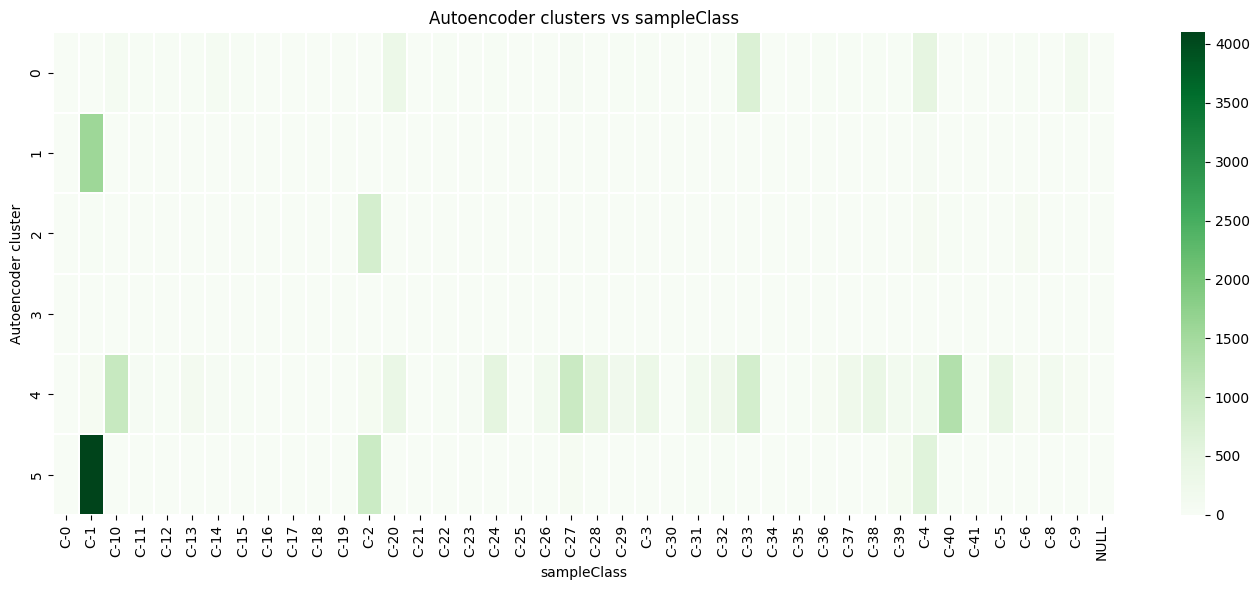

In [44]:
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_vs_class_ae, cmap="Greens", linewidths=0.3)
plt.title("Autoencoder clusters vs sampleClass")
plt.xlabel("sampleClass")
plt.ylabel("Autoencoder cluster")
plt.tight_layout()
plt.show()

In [45]:
valid_ae = merged_ae.dropna(subset=["sampleclass"]).copy()

true_ae = valid_ae["sampleclass"].astype("category").cat.codes
pred_ae = valid_ae["cluster"]

ari_ae = adjusted_rand_score(true_ae, pred_ae)
nmi_ae = normalized_mutual_info_score(true_ae, pred_ae)

print("Autoencoder ARI:", ari_ae)
print("Autoencoder NMI:", nmi_ae)

Autoencoder ARI: 0.18423567965962143
Autoencoder NMI: 0.3500918996836583


In [46]:
comparison = pd.DataFrame({
    "Method": ["Mean Shift", "Autoencoder + KMeans"],
    "Number of clusters": [len(pd.Series(labels_ms).unique()), len(pd.Series(latent_labels).unique())],
    "Silhouette": [ms_silhouette, ae_silhouette],
    "ARI": [ari_ms, ari_ae],
    "NMI": [nmi_ms, nmi_ae]
})

display(comparison)

,Method,Number of clusters,Silhouette,ARI,NMI
0,Mean Shift,12,0.317723,-0.006579,0.174656
1,Autoencoder + KMeans,6,0.584717,0.184236,0.350092


Overall, the Autoencoder + KMeans approach performs significantly better than Mean Shift. It achieves a higher silhouette score, indicating better cluster separation, and much higher ARI and NMI values, showing stronger agreement with the true sampleClass labels. This suggests that the autoencoder latent representation captures the underlying structure of the data more effectively than direct clustering on the original preprocessing features.

Compared to the Mean Shift result (0.318), this higher score suggests that the latent features learned by the autoencoder provide a clearer clustering structure with better separation between groups.

In [47]:
import pandas as pd

# PCA loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

# Show first two latent dimensions
print(pca_loadings[["PC1", "PC2"]].sort_values(by="PC1", ascending=False))

                             PC1       PC2
has_mass_in_jar         0.300699  0.074210
height                  0.226054  0.167015
has_drying              0.209509  0.100668
geometry_g-2            0.186943  0.046919
quantumunit_kg_kp       0.168170  0.046377
...                          ...       ...
dryweightnet_missing   -0.209509 -0.100668
quantumunit_m^3        -0.217225 -0.245486
massinjargross_missing -0.299914 -0.071641
massinjartare_missing  -0.299991 -0.071628
massinjar_missing      -0.300217 -0.074095

[64 rows x 2 columns]


In [48]:
print("Top features contributing to PC1:")
print(pca_loadings["PC1"].abs().sort_values(ascending=False).head(10))

print("\nTop features contributing to PC2:")
print(pca_loadings["PC2"].abs().sort_values(ascending=False).head(10))

Top features contributing to PC1:
has_mass_in_jar           0.300699
massinjar_missing         0.300217
massinjartare_missing     0.299991
massinjargross_missing    0.299914
height                    0.226054
quantumunit_m^3           0.217225
dryweightnet_missing      0.209509
has_drying                0.209509
weightnet_missing         0.191827
geometry_g-2              0.186943
Name: PC1, dtype: float64

Top features contributing to PC2:
geometry_missing       0.365419
height_missing         0.365419
quantum_missing        0.365419
density_missing        0.360115
quantumunit_missing    0.355512
has_sr_carrier         0.259905
quantumunit_m^3        0.245486
has_vaporization       0.188497
height                 0.167015
geometry_g-3           0.153065
Name: PC2, dtype: float64


In [49]:
print(len(feature_names))

64


In [50]:
feature_names = X_final_df.columns.tolist()

In [51]:
print("Number of features:", len(feature_names))

for i, col in enumerate(feature_names, 1):
    print(i, col)

Number of features: 64
1 weightnet
2 vacuumed
3 quantum
4 height
5 density
6 massinjar
7 massinjartare
8 massinjargross
9 dryweightnet
10 gross_less_than_tare
11 dry_gt_netwet
12 ash_gt_dry
13 dry_percent_gt_100
14 density_nonpositive
15 quality_error
16 has_mass_in_jar
17 has_drying
18 has_vaporization
19 has_ashing
20 has_sr_carrier
21 has_sieving
22 quantumunit_kg
23 quantumunit_kg_kp
24 quantumunit_kg_np
25 quantumunit_kg_tp
26 quantumunit_laaduton
27 quantumunit_litra
28 quantumunit_m^2
29 quantumunit_m^3
30 geometry_g-1
31 geometry_g-11
32 geometry_g-12
33 geometry_g-13
34 geometry_g-14
35 geometry_g-2
36 geometry_g-3
37 geometry_g-4
38 geometry_g-5
39 geometry_g-6
40 geometry_g-7
41 geometry_g-8
42 weightnet_missing
43 vacuumed_missing
44 quantum_missing
45 quantumunit_missing
46 geometry_missing
47 height_missing
48 density_missing
49 massinjar_missing
50 massinjartare_missing
51 massinjargross_missing
52 dryweightnet_missing
53 gross_less_than_tare_missing
54 dry_gt_netwet_mis

In [52]:
pd.DataFrame(feature_names, columns=["feature_name"])

,feature_name
0,weightnet
1,vacuumed
2,quantum
3,height
4,density
...,...
59,has_drying_missing
60,has_vaporization_missing
61,has_ashing_missing
62,has_sr_carrier_missing


In [53]:
print(X_pca.shape)

(20095, 28)


In [54]:
pca_features = [f"PCA_{i+1}" for i in range(X_pca.shape[1])]
print(pca_features)

['PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_19', 'PCA_20', 'PCA_21', 'PCA_22', 'PCA_23', 'PCA_24', 'PCA_25', 'PCA_26', 'PCA_27', 'PCA_28']


In [55]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PCA_{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

loadings[["PCA_1","PCA_2"]].sort_values("PCA_1", ascending=False)

,PCA_1,PCA_2
has_mass_in_jar,0.300699,0.074210
height,0.226054,0.167015
has_drying,0.209509,0.100668
geometry_g-2,0.186943,0.046919
quantumunit_kg_kp,0.168170,0.046377
...,...,...
dryweightnet_missing,-0.209509,-0.100668
quantumunit_m^3,-0.217225,-0.245486
massinjargross_missing,-0.299914,-0.071641
massinjartare_missing,-0.299991,-0.071628


In [56]:
print(loadings["PCA_1"].abs().sort_values(ascending=False).head(10))
print(loadings["PCA_2"].abs().sort_values(ascending=False).head(10))

has_mass_in_jar           0.300699
massinjar_missing         0.300217
massinjartare_missing     0.299991
massinjargross_missing    0.299914
height                    0.226054
quantumunit_m^3           0.217225
dryweightnet_missing      0.209509
has_drying                0.209509
weightnet_missing         0.191827
geometry_g-2              0.186943
Name: PCA_1, dtype: float64
geometry_missing       0.365419
height_missing         0.365419
quantum_missing        0.365419
density_missing        0.360115
quantumunit_missing    0.355512
has_sr_carrier         0.259905
quantumunit_m^3        0.245486
has_vaporization       0.188497
height                 0.167015
geometry_g-3           0.153065
Name: PCA_2, dtype: float64


In [57]:
pca_df = pd.DataFrame(X_pca, columns=[f"PCA_{i+1}" for i in range(X_pca.shape[1])])
pca_df.head()

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,...,PCA_19,PCA_20,PCA_21,PCA_22,PCA_23,PCA_24,PCA_25,PCA_26,PCA_27,PCA_28
0,-2.942380,-2.183080,0.335290,-0.638716,-0.003447,0.115232,-0.493603,0.384779,-0.212228,0.116389,...,-0.002798,-0.235943,-0.012226,-0.122534,0.462785,0.270105,0.073302,-0.196635,0.175369,-0.228176
1,-3.006370,-2.142902,0.834891,-1.298519,-0.063251,0.226481,-0.963281,-1.584979,0.234687,-0.599463,...,-0.090872,0.124049,-0.068348,0.208532,-0.957360,-0.595614,-0.593523,-0.039425,-0.480927,0.439692
2,-2.940254,-2.180237,0.334502,-0.636507,-0.003031,0.112347,-0.502900,0.378190,-0.211822,0.115937,...,-0.002783,-0.235883,-0.012344,-0.122635,0.463085,0.270311,0.074311,-0.196640,0.175953,-0.228653
3,-3.007043,-2.143801,0.835140,-1.299217,-0.063383,0.227393,-0.960341,-1.582895,0.234559,-0.599320,...,-0.090877,0.124030,-0.068310,0.208564,-0.957455,-0.595679,-0.593842,-0.039423,-0.481112,0.439842
4,-0.990963,0.450171,-2.324387,3.641542,0.354016,-2.494316,-1.228734,3.236936,-1.619761,0.349396,...,0.006334,0.473727,0.282088,0.448184,-0.578998,-0.389594,0.262643,0.685743,0.413546,-0.320229


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Reconstruct the input using the trained autoencoder
with torch.no_grad():
    X_reconstructed = model(X_tensor).numpy()

# 2. Reconstruction error per sample
reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

# 3. Threshold for anomalies
# top 5% highest reconstruction error = outliers
threshold = np.percentile(reconstruction_error, 95)

is_outlier = reconstruction_error >= threshold

# 4. Build result table with pseudoid
anomaly_df = pd.DataFrame({
    "pseudoid": pseudoids_final,
    "reconstruction_error": reconstruction_error,
    "is_outlier": is_outlier.astype(int)
})

# optional: attach autoencoder cluster labels if available
if "latent_labels" in globals():
    anomaly_df["cluster"] = latent_labels

# 5. Show summary
print("Threshold:", threshold)
print("Number of outliers:", anomaly_df["is_outlier"].sum())
display(anomaly_df.sort_values("reconstruction_error", ascending=False).head(20))

Threshold: 1.3003091332569967
Number of outliers: 1005


,pseudoid,reconstruction_error,is_outlier,cluster
15458,75948,78.667721,1,2
13495,73154,78.667577,1,2
12483,73722,78.666572,1,2
12635,77648,78.664227,1,2
6763,79244,66.563485,1,5
8064,54327,64.002628,1,1
383,61277,64.000433,1,1
663,51338,62.961915,1,1
664,57544,62.961915,1,1
10321,67876,62.959410,1,1


In [59]:
outliers_only = anomaly_df[anomaly_df["is_outlier"] == 1].copy()
display(outliers_only.head(20))

,pseudoid,reconstruction_error,is_outlier,cluster
60,64390,4.223224,1,1
97,62360,1.759853,1,4
98,62374,1.921614,1,4
111,59183,2.069475,1,5
120,62587,14.202219,1,0
121,74292,6.586461,1,0
168,78734,2.385238,1,5
179,69895,1.439926,1,5
212,75095,36.609949,1,3
213,56427,36.604192,1,3


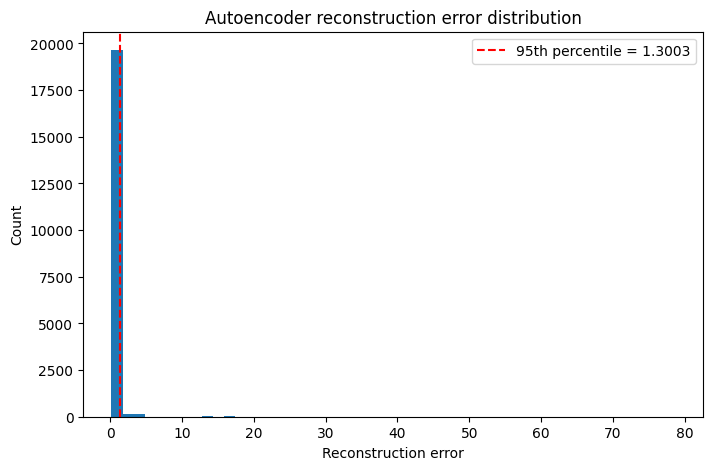

In [60]:
plt.figure(figsize=(8,5))
plt.hist(reconstruction_error, bins=50)
plt.axvline(threshold, color="red", linestyle="--", label=f"95th percentile = {threshold:.4f}")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.title("Autoencoder reconstruction error distribution")
plt.legend()
plt.show()

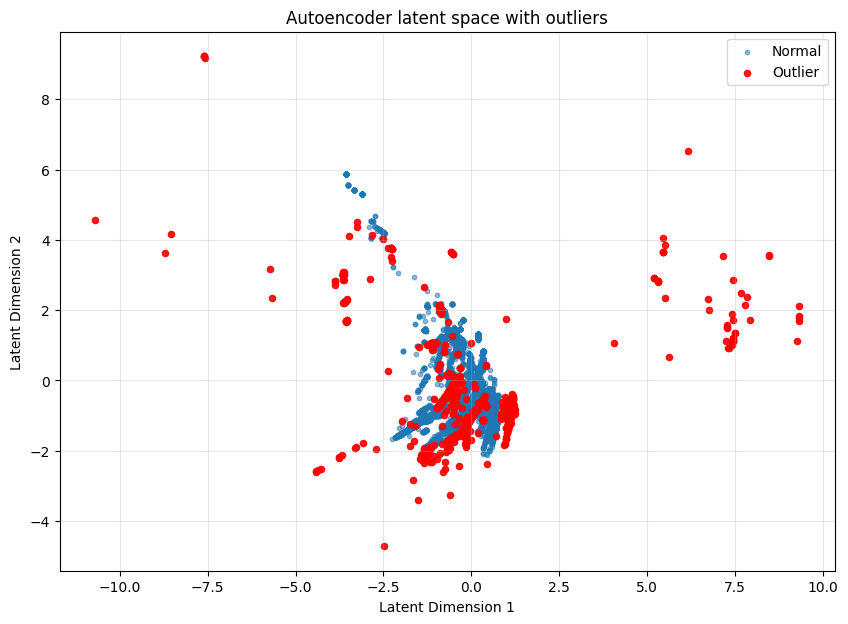

In [61]:
plt.figure(figsize=(10,7))

normal_mask = ~is_outlier
outlier_mask = is_outlier

plt.scatter(Z[normal_mask, 0], Z[normal_mask, 1], s=10, alpha=0.5, label="Normal")
plt.scatter(Z[outlier_mask, 0], Z[outlier_mask, 1], s=20, alpha=0.9, color="red", label="Outlier")

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Autoencoder latent space with outliers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [62]:
anomaly_df.sort_values("reconstruction_error", ascending=False).head(10)

,pseudoid,reconstruction_error,is_outlier,cluster
15458,75948,78.667721,1,2
13495,73154,78.667577,1,2
12483,73722,78.666572,1,2
12635,77648,78.664227,1,2
6763,79244,66.563485,1,5
8064,54327,64.002628,1,1
383,61277,64.000433,1,1
663,51338,62.961915,1,1
664,57544,62.961915,1,1
10321,67876,62.959410,1,1


In [63]:
outliers_only

,pseudoid,reconstruction_error,is_outlier,cluster
60,64390,4.223224,1,1
97,62360,1.759853,1,4
98,62374,1.921614,1,4
111,59183,2.069475,1,5
120,62587,14.202219,1,0
...,...,...,...,...
20022,54252,4.220772,1,1
20029,66975,2.267264,1,5
20031,78820,4.225927,1,1
20067,67021,1.349780,1,5


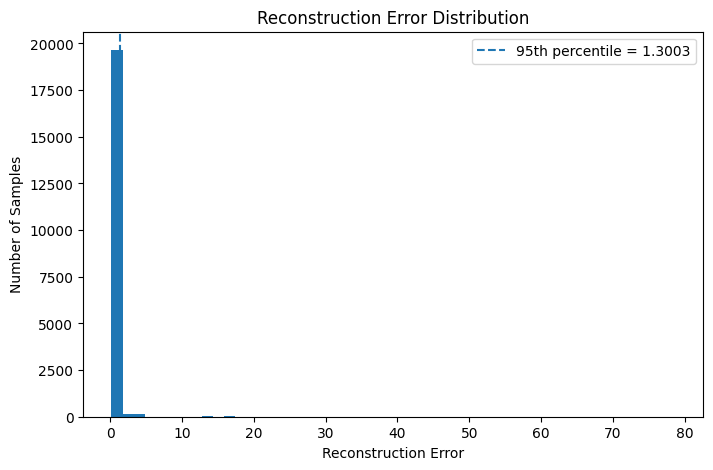

95th percentile threshold: 1.3003091332569967


In [64]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute threshold (95%)
threshold_95 = np.percentile(reconstruction_error, 95)

# 2. Plot histogram
plt.figure(figsize=(8,5))
plt.hist(reconstruction_error, bins=50)

# 3. Draw threshold line
plt.axvline(threshold_95, linestyle='--', label=f'95th percentile = {threshold_95:.4f}')

# 4. Labels
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Reconstruction Error Distribution")

# 5. Legend
plt.legend()

plt.show()

# 6. Print threshold
print("95th percentile threshold:", threshold_95)

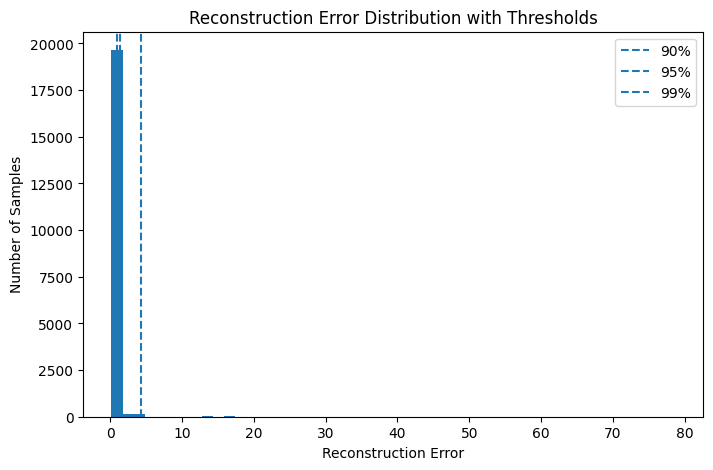

90%: 0.9487235348459314
95%: 1.3003091332569967
99%: 4.275553844466191


In [65]:
p90 = np.percentile(reconstruction_error, 90)
p95 = np.percentile(reconstruction_error, 95)
p99 = np.percentile(reconstruction_error, 99)

plt.figure(figsize=(8,5))
plt.hist(reconstruction_error, bins=50)

plt.axvline(p90, linestyle='--', label='90%')
plt.axvline(p95, linestyle='--', label='95%')
plt.axvline(p99, linestyle='--', label='99%')

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Reconstruction Error Distribution with Thresholds")
plt.legend()

plt.show()

print("90%:", p90)
print("95%:", p95)
print("99%:", p99)

In [66]:
anomaly_df[anomaly_df["is_outlier"] == 1].shape

(1005, 4)

In [67]:
anomaly_df.sort_values("reconstruction_error", ascending=False).head(10)

,pseudoid,reconstruction_error,is_outlier,cluster
15458,75948,78.667721,1,2
13495,73154,78.667577,1,2
12483,73722,78.666572,1,2
12635,77648,78.664227,1,2
6763,79244,66.563485,1,5
8064,54327,64.002628,1,1
383,61277,64.000433,1,1
663,51338,62.961915,1,1
664,57544,62.961915,1,1
10321,67876,62.959410,1,1


In [68]:
import numpy as np

percentiles = list(range(90, 101))  # 90 to 100

for p in percentiles:
    value = np.percentile(reconstruction_error, p)
    print(f"{p}%: {value}")

90%: 0.9487235348459314
91%: 1.006566806941926
92%: 1.1078686137676481
93%: 1.1750773416436502
94%: 1.19192402734278
95%: 1.3003091332569967
96%: 1.4270788106525212
97%: 1.4970905329596107
98%: 1.8256973272890642
99%: 4.275553844466191
100%: 78.66772133300148


In [69]:
import pandas as pd

percentiles = list(range(90, 101))

threshold_table = pd.DataFrame({
    "percentile": percentiles,
    "threshold": [np.percentile(reconstruction_error, p) for p in percentiles]
})

display(threshold_table)

,percentile,threshold
0,90,0.948724
1,91,1.006567
2,92,1.107869
3,93,1.175077
4,94,1.191924
5,95,1.300309
6,96,1.427079
7,97,1.497091
8,98,1.825697
9,99,4.275554


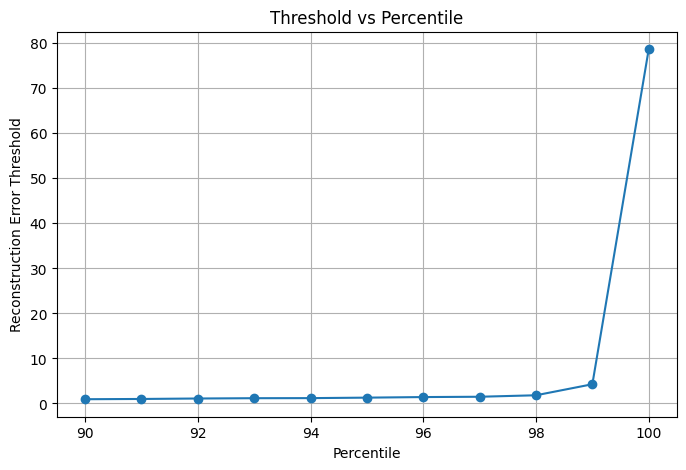

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(threshold_table["percentile"], threshold_table["threshold"], marker='o')

plt.xlabel("Percentile")
plt.ylabel("Reconstruction Error Threshold")
plt.title("Threshold vs Percentile")

plt.grid()
plt.show()

In [71]:
import pandas as pd
import numpy as np

threshold = 1.3003091332569967  # your 95% threshold

anomaly_df = pd.DataFrame({
    "pseudoid": pseudoids_final,
    "reconstruction_error": reconstruction_error
})

# mark outliers
anomaly_df["is_outlier"] = (anomaly_df["reconstruction_error"] > threshold).astype(int)

In [72]:
outliers = anomaly_df[anomaly_df["is_outlier"] == 1].copy()

print("Number of outliers:", len(outliers))
display(outliers)

Number of outliers: 1005


,pseudoid,reconstruction_error,is_outlier
60,64390,4.223224,1
97,62360,1.759853,1
98,62374,1.921614,1
111,59183,2.069475,1
120,62587,14.202219,1
...,...,...,...
20022,54252,4.220772,1
20029,66975,2.267264,1
20031,78820,4.225927,1
20067,67021,1.349780,1


In [ ]:
outliers_full = df.merge(outliers_sorted, on="pseudoid")
outliers_full.to_csv("outliers_full_analysis.csv", index=False)

In [74]:
outliers_only.to_csv("outliers_all_1005.csv", index=False)
print("Saved successfully: outliers_all_1005.csv")

Saved successfully: outliers_all_1005.csv


In [75]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(outliers_only)

      pseudoid  reconstruction_error  is_outlier  cluster
60       64390              4.223224           1        1
97       62360              1.759853           1        4
98       62374              1.921614           1        4
111      59183              2.069475           1        5
120      62587             14.202219           1        0
121      74292              6.586461           1        0
168      78734              2.385238           1        5
179      69895              1.439926           1        5
212      75095             36.609949           1        3
213      56427             36.604192           1        3
226      60984              4.222786           1        1
227      65856              1.414250           1        5
236      56395             35.067133           1        3
297      72900             35.765658           1        3
298      51593             35.765658           1        3
299      50993             35.765658           1        3
332      55880

In [76]:
threshold_98 = np.percentile(reconstruction_error, 98)
print("98% threshold:", threshold_98)

98% threshold: 1.8256973272890642


In [77]:
outliers_98 = pd.DataFrame({
    "pseudoid": pseudoids_final,
    "reconstruction_error": reconstruction_error
})

outliers_98["is_outlier"] = (outliers_98["reconstruction_error"] > threshold_98).astype(int)

In [78]:
outliers_98_only = outliers_98[outliers_98["is_outlier"] == 1].copy()
outliers_98_only = outliers_98_only.reset_index(drop=True)

print("Number of outliers (98%):", len(outliers_98_only))
display(outliers_98_only)

Number of outliers (98%): 402


,pseudoid,reconstruction_error,is_outlier
0,64390,4.223224,1
1,62374,1.921614,1
2,59183,2.069475,1
3,62587,14.202219,1
4,74292,6.586461,1
5,78734,2.385238,1
6,75095,36.609949,1
7,56427,36.604192,1
8,60984,4.222786,1
9,56395,35.067133,1


In [79]:
outliers_98_only.to_csv("outliers_98_percent.csv", index=False)

In [81]:
threshold_99 = np.percentile(reconstruction_error, 99)
print("99% threshold:", threshold_99)

99% threshold: 4.275553844466191


In [82]:
outliers_99 = pd.DataFrame({
    "pseudoid": pseudoids_final,
    "reconstruction_error": reconstruction_error
})

outliers_99["is_outlier"] = (outliers_99["reconstruction_error"] > threshold_99).astype(int)

In [83]:
outliers_99_only = outliers_99[outliers_99["is_outlier"] == 1].copy()
outliers_99_only = outliers_99_only.reset_index(drop=True)

print("Number of outliers (99%):", len(outliers_99_only))
display(outliers_99_only)

Number of outliers (99%): 201


,pseudoid,reconstruction_error,is_outlier
0,62587,14.202219,1
1,74292,6.586461,1
2,75095,36.609949,1
3,56427,36.604192,1
4,56395,35.067133,1
5,72900,35.765658,1
6,51593,35.765658,1
7,50993,35.765658,1
8,61277,64.000433,1
9,59547,35.066457,1


In [84]:
outliers_99_only.to_csv("outliers_99_percent.csv", index=False)

In [85]:
import pandas as pd

# load raw dataset
raw_df = pd.read_csv("dataset1_280126.csv")

# clean column names same way as before
raw_df.columns = (
    raw_df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "", regex=False)
)

# make sure pseudoid format matches
raw_df["pseudoid"] = raw_df["pseudoid"].astype(str).str.strip()
outliers_98_only["pseudoid"] = outliers_98_only["pseudoid"].astype(str).str.strip()

# merge anomaly list with full raw rows
outliers_98_full = raw_df.merge(outliers_98_only, on="pseudoid", how="inner")

print("Number of outliers (98%):", len(outliers_98_full))
display(outliers_98_full)

Number of outliers (98%): 402


,pseudoid,weightnet,vacuumed,quantum,quantumunit,geometry,height,density,massinjar,massinjartare,massinjargross,dryweightnet,dryweightpercent,totalvaporizationamount,totalvaporizationvolume,ashweightnet,amounttoashing,ashconcentration,srcarrierconcentration,srcarriervolume,sievedorganicweight,sievedrocksweight,sieveddryweight,reconstruction_error,is_outlier
0,64390,NaN,0,21621.200000,m^3,g-11,0.0,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.223224,1
1,62374,NaN,0,0.092550,kg,g-3,10.0,6.6800,92.549,0.0000,92.54850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.921614,1
2,59183,NaN,0,207795.000000,m^3,g-14,0.0,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.069475,1
3,62587,NaN,0,0.074740,kg,g-2,1.0,17.3800,74.736,27.0150,101.75150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.202219,1
4,74292,NaN,0,0.051860,kg,g-2,1.0,12.0600,51.855,27.0150,78.87020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.586461,1
5,78734,NaN,0,229640.000000,m^3,g-14,0.0,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.385238,1
6,75095,NaN,0,0.530960,kg,g-1,1.0,0.0000,530.960,132.7400,663.70000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.609949,1
7,56427,NaN,0,0.525380,kg,g-1,1.0,0.0000,525.380,133.4200,658.80000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.604192,1
8,60984,NaN,0,20847.700000,m^3,g-11,0.0,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.222786,1
9,56395,1407.80,0,0.011180,kg_kp,g-3,11.0,1.0000,NaN,22.4100,11.23000,12.30,0.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.067133,1


In [86]:
outliers_98_full.to_csv("outliers_98_full_rawdata.csv", index=False)
print("Saved: outliers_98_full_rawdata.csv")

Saved: outliers_98_full_rawdata.csv
